# Análisis Exploratorio de Datos (EDA) — Laboratorio 02: Red Neuronal Superficial para Deterioro Cognitivo

Este notebook documenta el análisis exploratorio del conjunto de datos utilizado en el
**Laboratorio 02**, cuyo objetivo es entrenar una **red neuronal superficial** (*Shallow Neural Network*)
en PyTorch para clasificar el deterioro cognitivo medido a través de la escala GDS
(*Global Deterioration Scale*) y sus cinco recodificaciones alternativas (`GDS_R1` – `GDS_R5`).

El objetivo de esta fase exploratoria es:
1. Verificar la **integridad** de los datos (dimensionalidad, valores nulos).
2. Cuantificar el **desbalance de clases** en las seis variables objetivo y motivar
   las decisiones de diseño del pipeline de entrenamiento.
3. Seleccionar las **características más relevantes** mediante la prueba estadística χ² de Pearson,
   aplicada **antes** de cualquier transformación, garantizando así que el ranking
   refleje la dependencia estadística real entre los atributos y la variable objetivo.

---
## 1. Carga de Datos y Verificación de Dimensionalidad

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_FILEPATH = '../data/raw/15 atributos R0-R5.sav'
df = pd.read_spss(DATASET_FILEPATH)

In [2]:
total_rows, total_cols = df.shape
print(f"Dimensionalidad del dataset: {total_rows} filas × {total_cols} columnas")
display(df.head())

Dimensionalidad del dataset: 1119 filas × 22 columnas


,ID,Día,Mes,Año,Estación,País,Ciudad,CalleLugar,NumeroPiso,Miguel2,...,Imperial2,A682,Caldera2,Copiapo2,GDS,GDS_R1,GDS_R2,GDS_R3,GDS_R4,GDS_R5
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,3.0,1.0,2.0,1.0,2.0,2.0
1,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
2,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,4.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,2.0,1.0,1.0,1.0,2.0,2.0
4,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,1.0,1.0,2.0,2.0


### 1.1 Verificación de Valores Nulos

In [3]:
null_count_per_column = df.isnull().sum()
total_null_count = null_count_per_column.sum()

print(f"Total de valores nulos en el dataset: {total_null_count}")
print(f"Verificación matemática: {total_rows} filas × {total_cols} columnas "
      f"= {total_rows * total_cols} celdas totales")
print(f"Celdas no nulas: {df.notna().sum().sum()}")
print(f"Proporción de nulos: {total_null_count}/{total_rows * total_cols} = "
      f"{total_null_count / (total_rows * total_cols) * 100:.4f}%")

if total_null_count > 0:
    print("\nColumnas con valores nulos:")
    print(null_count_per_column[null_count_per_column > 0])

> **Conclusión de integridad:** El dataset puede presentar valores nulos en
> algunas de sus variables. El pipeline de entrenamiento aborda esta situación mediante
> **imputación robusta** (`SimpleImputer`) en lugar de eliminar filas, preservando así
> la totalidad de las 1 119 observaciones disponibles:
>
> - **Columnas numéricas continuas:** imputación por la **mediana** (robusta a valores atípicos).
> - **Columnas binarias:** imputación por la **moda** (*most_frequent*).
>
> Esta estrategia garantiza que el entrenamiento de la red neuronal se realice
> sobre el conjunto de datos completo, sin pérdida de información.

---
## 2. Análisis del Desbalance de Clases en las Seis Codificaciones GDS

La variable clínica objetivo admite **seis codificaciones** distintas
(`GDS`, `GDS_R1`, `GDS_R2`, `GDS_R3`, `GDS_R4`, `GDS_R5`), cada una de las cuales
asigna los pacientes a diferentes niveles de gravedad del deterioro cognitivo.
A continuación se presenta la distribución de pacientes por nivel para cada
codificación.

In [4]:
TARGET_COLUMNS = ['GDS', 'GDS_R1', 'GDS_R2', 'GDS_R3', 'GDS_R4', 'GDS_R5']

for target in TARGET_COLUMNS:
    counts = df[target].value_counts().sort_index()
    percentages = (counts / counts.sum() * 100).round(2)
    summary = pd.DataFrame({
        'Cantidad': counts,
        'Porcentaje (%)': percentages
    })
    summary.index.name = target
    print(f"\n{'='*55}")
    print(f"  Distribución de clases para: {target}")
    print(f"{'='*55}")
    display(summary)


  Distribución de clases para: GDS


,Cantidad,Porcentaje (%)
GDS,,
1.0,149,13.32
2.0,500,44.68
3.0,298,26.63
4.0,108,9.65
5.0,42,3.75
6.0,20,1.79
7.0,2,0.18



  Distribución de clases para: GDS_R1


,Cantidad,Porcentaje (%)
GDS_R1,,
1.0,947,84.63
2.0,150,13.40
3.0,22,1.97



  Distribución de clases para: GDS_R2


...

,Cantidad,Porcentaje (%)
GDS_R3,,
1.0,947,84.63
3.0,172,15.37



  Distribución de clases para: GDS_R4


,Cantidad,Porcentaje (%)
GDS_R4,,
1.0,149,13.32
2.0,906,80.97
3.0,64,5.72



  Distribución de clases para: GDS_R5


,Cantidad,Porcentaje (%)
GDS_R5,,
1.0,149,13.32
2.0,798,71.31
3.0,172,15.37


### 2.1 Gráfico Comparativo de Barras Agrupadas

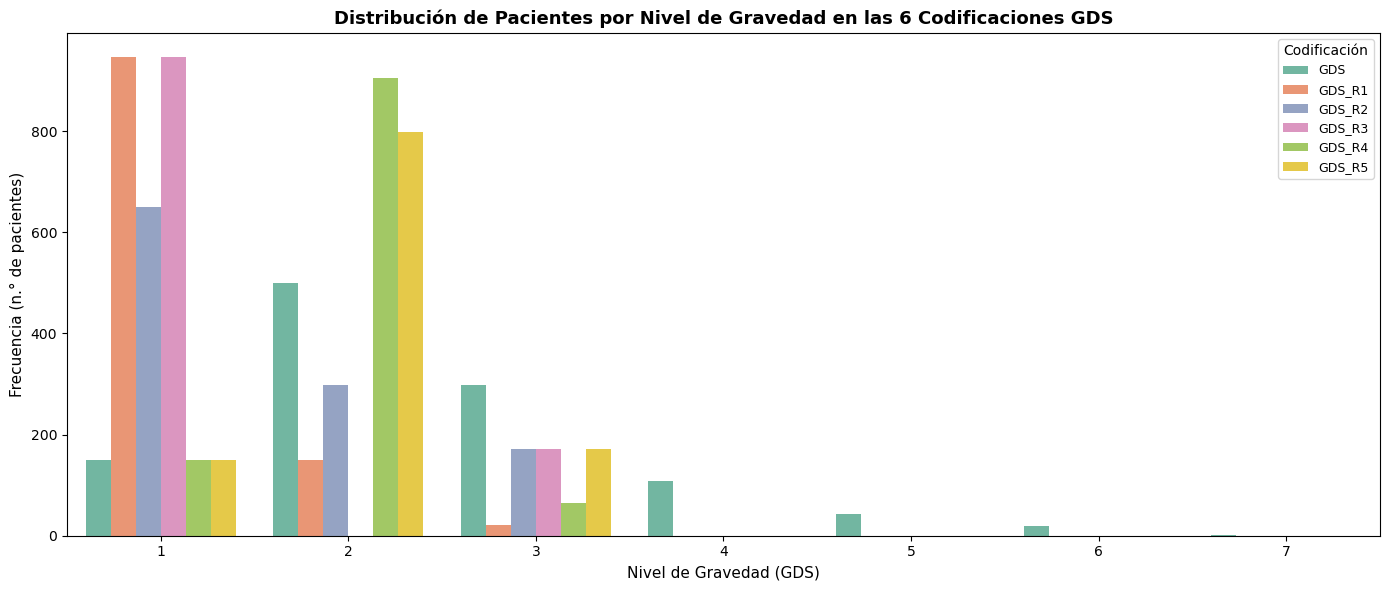

In [5]:
all_levels = sorted(df[TARGET_COLUMNS].stack().unique())

distribution_records = []
for target in TARGET_COLUMNS:
    counts = df[target].value_counts()
    for level in all_levels:
        distribution_records.append({
            'Nivel GDS': int(level),
            'Codificación': target,
            'Frecuencia': counts.get(level, 0)
        })

distribution_df = pd.DataFrame(distribution_records)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=distribution_df,
    x='Nivel GDS',
    y='Frecuencia',
    hue='Codificación',
    palette='Set2'
)
plt.title('Distribución de Pacientes por Nivel de Gravedad en las 6 Codificaciones GDS',
          fontsize=13, fontweight='bold')
plt.xlabel('Nivel de Gravedad (GDS)', fontsize=11)
plt.ylabel('Frecuencia (n.° de pacientes)', fontsize=11)
plt.legend(title='Codificación', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()

> **Interpretación — Desbalance extremo:**
>
> En todas las codificaciones se observa un **desbalance severo** de clases.
> Los niveles de gravedad bajos (clases 1 y 2) concentran la gran mayoría de los
> pacientes, mientras que los niveles más altos (clases 5, 6 y 7) representan
> fracciones marginales del conjunto de datos — en algunos casos por debajo del 1 %.
>
> Este desbalance tiene implicaciones directas sobre el diseño del pipeline de
> entrenamiento implementado en este laboratorio:
> - Un clasificador ingenuo que prediga siempre la clase mayoritaria alcanzaría
>   métricas de *accuracy* engañosamente altas sin aportar valor clínico.
> - La evaluación se basa en métricas robustas al desbalance
>   (*macro F1-score*, *Hamming Loss*, *recall* por clase, *precision* por clase).
> - Se emplea **`BCEWithLogitsLoss` con pesos positivos** (`pos_weight`) calculados
>   dinámicamente como `neg / pos` por cada clase, penalizando más los errores sobre
>   las clases minoritarias y compensando el desbalance sin necesidad de sobremuestreo.
> - La **Validación Cruzada Anidada** (`NestedCrossValidator`) utiliza
>   `MultilabelStratifiedKFold` (librería `iterative-stratification`) para garantizar
>   que cada *fold* preserve la proporción original de clases en las seis variables
>   objetivo simultáneamente.

---
## 3. Selección de Características mediante χ² de Pearson

Un aspecto metodológico fundamental es realizar la selección de características
**sobre los datos originales**. Si se seleccionaran características después de
alterar la distribución de clases, los *scores* estarían
contaminados por las instancias sintéticas, lo que produciría un ranking
artificialmente inflado y estadísticamente inválido (*data leakage*).

### Procedimiento
1. Se aíslan los **atributos predictivos** eliminando la columna `ID` y las
   seis variantes de GDS.
2. Se utiliza `SelectKBest` con `score_func=chi2` y `k='all'` para obtener el
   *score* χ² de cada atributo respecto a la variable objetivo `GDS`.
3. Se presenta un ranking ordenado y un gráfico de barras horizontales.

> **Nota:** El pipeline de entrenamiento (`src/main.py`) utiliza los **15 atributos**
> disponibles para maximizar la información disponible a la red neuronal superficial,
> que es capaz de aprender representaciones internas. El análisis χ² aquí presentado
> sirve para comprender la dependencia estadística de cada atributo con el objetivo.

In [6]:
from sklearn.feature_selection import SelectKBest, chi2

NON_PREDICTIVE_COLUMNS = ['ID'] + TARGET_COLUMNS
predictive_columns = [col for col in df.columns if col not in NON_PREDICTIVE_COLUMNS]

X_original = df[predictive_columns]
y_original = df['GDS']

selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_original, y_original)

chi2_ranking = pd.DataFrame({
    'Atributo': predictive_columns,
    'Score χ²': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values(by='Score χ²', ascending=False).reset_index(drop=True)

chi2_ranking.index = chi2_ranking.index + 1
chi2_ranking.index.name = 'Ranking'

print("Ranking de atributos por Score χ² (datos originales):\n")
display(chi2_ranking)

### 3.1 Gráfico de Importancia de Atributos (χ²)

In [7]:
sorted_ranking = chi2_ranking.sort_values(by='Score χ²', ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.magma(np.linspace(0.2, 0.85, len(sorted_ranking)))
plt.barh(sorted_ranking['Atributo'], sorted_ranking['Score χ²'], color=colors)
plt.title('Importancia de Atributos — Score χ² (Datos Originales)',
          fontsize=13, fontweight='bold')
plt.xlabel('Score χ² de Pearson', fontsize=11)
plt.ylabel('Atributo', fontsize=11)
plt.tight_layout()
plt.show()

### 3.2 Top 10 de Atributos Seleccionados

In [8]:
TOP_K = 10
top_features = chi2_ranking.head(TOP_K)['Atributo'].tolist()

print(f"Las {TOP_K} variables con mayor dependencia estadística respecto a GDS son:\n")
for i, feature in enumerate(top_features, start=1):
    score = chi2_ranking.loc[chi2_ranking['Atributo'] == feature, 'Score χ²'].iloc[0]
    print(f"  {i:>2}. {feature:<15s}  (χ² = {score:.2f})")

> **Conclusión — Selección de características:**
>
> Las **10 variables** listadas anteriormente presentan los mayores valores del
> estadístico χ² de Pearson, lo que indica una **dependencia estadística clínicamente
> significativa** con el nivel de deterioro cognitivo (`GDS`).
>
> El pipeline de entrenamiento del Laboratorio 02 (`src/main.py`) utiliza los
> **15 atributos** disponibles, aprovechando la capacidad de la red neuronal
> superficial para aprender representaciones internas ponderadas. Al haber realizado
> esta selección **sobre los datos originales** (sin remuestreo), el ranking obtenido
> refleja fielmente la relación real entre cada atributo y la variable objetivo,
> evitando el sesgo que introduciría el sobremuestreo sintético.

---
## 4. Arquitectura del Pipeline de Entrenamiento (Lab 02)

El pipeline implementado en `src/main.py` entrena **6 modelos independientes**,
uno por cada variable objetivo (`GDS`, `GDS_R1`–`GDS_R5`), siguiendo el flujo:

### 4.1 Preprocesamiento (`DataPreprocessor`)
- **Imputación** de valores nulos: mediana para columnas numéricas, moda para binarias.
- **Escalado** estándar (`StandardScaler`) de todas las características.
- **Codificación One-Hot** de la variable objetivo multiclase → representación *multilabel*
  compatible con `BCEWithLogitsLoss`.

### 4.2 Arquitectura de la Red (`ShallowNeuralNetwork`)
```
Entrada (15 features)
    → Linear(15, hidden_dim)   [hidden_dim ∈ {32, 64, 128}]
    → ReLU
    → Dropout(p)
    → Linear(hidden_dim, n_clases)
    → [logits sin activación — BCEWithLogitsLoss los procesa internamente]
```

### 4.3 Estrategia de Evaluación (`NestedCrossValidator`)
- **Bucle externo** (5 *folds*): estima la generalización del modelo.
- **Bucle interno** (3 *folds*): selecciona los mejores hiperparámetros.
- Estratificación multilabel via `MultilabelStratifiedKFold` (librería `iterative-stratification`).
- Métrica de optimización interna: **F1 Micro**.

### 4.4 Manejo del Desbalance
- `BCEWithLogitsLoss` con `pos_weight = num_negatives / num_positives` por clase,
  calculado dinámicamente en cada *fold*.

### 4.5 Estimación de Incertidumbre (`MonteCarloDropoutEstimator`)
- Tras el entrenamiento final, se realizan **50 pases hacia adelante** con Dropout
  activo (*modo train*) para estimar la incertidumbre predictiva del modelo.
- Se reportan la **media** y la **desviación estándar** de las probabilidades como
  medida de confianza en la predicción.

### 4.6 Métricas de Evaluación Reportadas
| Métrica | Descripción |
|---|---|
| Hamming Loss | Proporción de etiquetas predichas incorrectamente |
| Precision Micro | Precisión promediada micro sobre todas las clases |
| Recall Micro | Recall promediado micro sobre todas las clases |
| F1 Micro | Media armónica micro de precision y recall |
| F1 Macro | Media aritmética del F1 por clase |
| Exact Match | Accuracy de subconjunto (predicción exacta del vector multilabel) |